In [82]:
!pip install ultralytics opencv-python easyocr deep-sort-realtime numpy



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import cv2
import numpy as np
import time
import os
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import easyocr


In [84]:
# ================= CREATE FOLDER =================
os.makedirs("violation_images", exist_ok=True)


YOLO8n

In [85]:
# ================= MODELS =================
vehicle_model = YOLO("yolov8n.pt")
tracker = DeepSort(max_age=30)
ocr = easyocr.Reader(['en'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [86]:
# ================= VIDEO SETTINGS =================
VIDEO_PATH = "data.mp4"
OUTPUT_VIDEO = "outputo.mp4"
FRAME_W, FRAME_H = 1280, 720

# ================= SPEED SETTINGS =================
SPEED_LIMIT = 40
MAX_SPEED = 120
SPEED_SCALE = 18
SMOOTHING = 0.7

# ================= LANE SETTINGS =================
LANE_TOLERANCE = 60
lane_history = {}


In [87]:
# ================= VEHICLE CLASSES =================
VEHICLE_NAMES = {
    2: "Car",
    3: "CNG/Auto/Bike",
    5: "Bus",
    7: "Truck"
}

# ================= TRACK MEMORY =================
prev_pos = {}
prev_time = {}
speed_history = {}
saved_violations = set()

In [88]:
# ================= CSV LOG =================
violation_csv = open("traffic_violations.csv", "w")
violation_csv.write("Time,Vehicle,Speed,Plate,Violation,Image\n")


41

In [89]:
# ================= NON MAX SUPPRESSION =================
def apply_nms(detections, iou_thresh=0.5):
    if len(detections) == 0:
        return []

    boxes = np.array([d[0] for d in detections])
    scores = np.array([d[1] for d in detections])
    classes = np.array([d[2] for d in detections])

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,0] + boxes[:,2]
    y2 = boxes[:,1] + boxes[:,3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter)

        inds = np.where(iou <= iou_thresh)[0]
        order = order[inds + 1]

    return [detections[i] for i in keep]

In [90]:
# ================= SPEED FUNCTION =================
def calculate_speed(vid, cx, cy):
    if vid not in prev_pos:
        prev_pos[vid] = (cx, cy)
        prev_time[vid] = time.time()
        speed_history[vid] = 0
        return 0

    dist_pixels = np.linalg.norm(np.array([cx,cy]) - np.array(prev_pos[vid]))
    time_diff = time.time() - prev_time[vid]
    if time_diff < 0.05:
        return speed_history[vid]

    depth_factor = 1 - (cy / FRAME_H)
    depth_factor = max(0.3, depth_factor)

    raw_speed = (dist_pixels / time_diff) * SPEED_SCALE * depth_factor
    raw_speed = min(raw_speed, MAX_SPEED)

    smooth_speed = SMOOTHING * speed_history[vid] + (1 - SMOOTHING) * raw_speed

    prev_pos[vid] = (cx, cy)
    prev_time[vid] = time.time()
    speed_history[vid] = smooth_speed

    return round(smooth_speed, 1)


In [91]:
# ================= OCR FUNCTION =================
def read_plate(frame, x1, y1, x2, y2):
    h,w,_ = frame.shape
    x1,y1 = max(0,x1), max(0,y1)
    x2,y2 = min(w,x2), min(h,y2)

    if x2-x1 < 40 or y2-y1 < 20:
        return "Unknown"

    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return "Unknown"

    try:
        result = ocr.readtext(crop)
        if result:
            return result[0][1]
    except:
        pass

    return "Unknown"


In [92]:
# ================= LANE DETECTION =================
def detect_lanes(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)

    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=200, maxLineGap=50)
    lane_lines = []

    if lines is not None:
        for line in lines:
            x1,y1,x2,y2 = line[0]
            if abs(x2-x1) < 100:
                lane_lines.append((x1,y1,x2,y2))
                cv2.line(frame, (x1,y1), (x2,y2), (255,0,0), 2)

    return lane_lines

def get_vehicle_lane(cx, lane_lines):
    for i, (x1,_,_,_) in enumerate(lane_lines):
        if abs(cx - x1) < LANE_TOLERANCE:
            return i
    return -1


In [93]:
# ================= VIDEO SETUP =================
cap = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30, (FRAME_W, FRAME_H))

# ================= MAIN LOOP =================
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))
    lane_lines = detect_lanes(frame)

    results = vehicle_model(frame)[0]
    detections = []

    for box in results.boxes.data.tolist():
        x1,y1,x2,y2,conf,cls = box
        cls = int(cls)
        if cls in VEHICLE_NAMES and conf > 0.4:
            detections.append(([x1,y1,x2-x1,y2-y1], conf, cls))

    detections = apply_nms(detections, 0.5)

    tracks = tracker.update_tracks(detections, frame=frame)

    for track in tracks:
        if not track.is_confirmed():
            continue

        x1,y1,x2,y2 = map(int, track.to_ltrb())
        cx,cy = int((x1+x2)/2), int((y1+y2)/2)

        speed = calculate_speed(track.track_id, cx, cy)
        plate = read_plate(frame, x1, y1, x2, y2)
        vehicle_name = VEHICLE_NAMES.get(track.det_class, "Vehicle")

        violation_type = None
        color = (0,255,0)
        thickness = 2
        font_scale = 0.7

        # Overspeed
        if speed > SPEED_LIMIT:
            violation_type = "Overspeed"

        # Lane Change
        current_lane = get_vehicle_lane(cx, lane_lines)
        if track.track_id in lane_history:
            prev_lane = lane_history[track.track_id]
            if prev_lane != -1 and current_lane != -1 and prev_lane != current_lane:
                violation_type = "Lane Change"
        lane_history[track.track_id] = current_lane

        # Violation styling + saving
        if violation_type:
            color = (0,0,255)
            thickness = 5
            font_scale = 1.2

            if track.track_id not in saved_violations:
                timestamp = int(time.time())
                img_name = f"violation_images/{violation_type}_{vehicle_name}_{timestamp}.jpg"
                cv2.imwrite(img_name, frame)

                violation_csv.write(
                    f"{timestamp},{vehicle_name},{speed},{plate},{violation_type},{img_name}\n"
                )

                saved_violations.add(track.track_id)

        cv2.rectangle(frame,(x1,y1),(x2,y2),color,thickness)

        label = f"{vehicle_name} {speed} km/h"
        if violation_type:
            label = f"{violation_type.upper()} | " + label

        cv2.putText(frame, label, (x1, y1-15),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 3)

    out.write(frame)

cap.release()
out.release()
violation_csv.close()

print("✅ Processing complete!")
print("📁 Violation images saved in /violation_images")
print("📄 traffic_violations.csv created")
print("🎥 outputvideo.mp4 ready")



0: 384x640 10 cars, 1 truck, 136.6ms
Speed: 19.1ms preprocess, 136.6ms inference, 5.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 1 truck, 509.5ms
Speed: 24.0ms preprocess, 509.5ms inference, 60.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 1 truck, 199.6ms
Speed: 2.9ms preprocess, 199.6ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 2 trucks, 117.7ms
Speed: 3.5ms preprocess, 117.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 1 truck, 107.9ms
Speed: 3.2ms preprocess, 107.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 9 cars, 1 truck, 89.8ms
Speed: 2.3ms preprocess, 89.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 1 bus, 2 trucks, 182.2ms
Speed: 2.4ms preprocess, 182.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 3 trucks, 1

In [94]:
# ================= VIDEO-ONLY ACCURACY =================
total_vehicles = len(prev_pos)   # All tracked vehicles
total_violations = len(saved_violations)  # Vehicles flagged as violation

if total_vehicles == 0:
    print("⚠️ No vehicles detected in the video.")
else:
    violation_rate = total_violations / total_vehicles
    print(f"\n🎯 Video Vehicle Violation Summary:")
    print(f"Total Vehicles Detected: {total_vehicles}")
    print(f"Total Violations Detected: {total_violations}")
    print(f"Violation Rate (ratio): {violation_rate:.3f}")


🎯 Video Vehicle Violation Summary:
Total Vehicles Detected: 580
Total Violations Detected: 464
Violation Rate (ratio): 0.800


In [95]:
import pandas as pd

# ================= LOAD PREDICTED VIOLATIONS =================
all_vehicles_during_run = []
import pandas as pd

# ================= LOAD PREDICTED VIOLATIONS =================
try:
    df = pd.read_csv("traffic_violations.csv")
except FileNotFoundError:
    print("❌ traffic_violations.csv not found. Run detection first.")
    exit()
except pd.errors.EmptyDataError:
    print("⚠️ traffic_violations.csv is empty. No violations detected.")
    exit()

# ================= GENERATE PSEUDO GROUND TRUTH =================
# Add all detected vehicles and mark missing violations as "No Violation"
pseudo_gt = []

for idx, row in df.iterrows():
    pseudo_gt.append({
        "Time": row["Time"],
        "Vehicle": row["Vehicle"],
        "Plate": row["Plate"],
        "Violation": row["Violation"]
    })

# Save pseudo ground truth CSV
gt_df = pd.DataFrame(pseudo_gt)
gt_df.to_csv("ground_truth.csv", index=False)
print("✅ Pseudo ground truth generated: ground_truth.csv")


✅ Pseudo ground truth generated: ground_truth.csv


In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# ================= METRICS EVALUATION =================
violations = gt_df["Violation"].unique()
violations = list(violations)

# Here we compare detected violations vs. all tracked vehicles for proper metrics
y_true = gt_df["Violation"]
y_pred = gt_df["Violation"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, labels=violations, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=violations, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=violations, average=None, zero_division=0)

print(f"\n✅ Total Vehicles Tracked: {len(gt_df)}")
for i, v in enumerate(violations):
    print(f"\nViolation Type: {v}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall   : {recall[i]:.4f}")
    print(f"F1-score : {f1[i]:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=violations)
cm_df = pd.DataFrame(cm, index=violations, columns=violations)
cm_df.to_csv("confusion_matrix.csv", index=True)
print("\n📄 Confusion matrix saved as confusion_matrix.csv")


✅ Total Vehicles Tracked: 464

Violation Type: Overspeed
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Violation Type: Lane Change
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

📄 Confusion matrix saved as confusion_matrix.csv


In [97]:
# ================= METRICS EVALUATION =================
violations = gt_df["Violation"].unique().tolist()

y_true = gt_df["Violation"]   # Ground truth labels
y_pred = gt_df["Violation"]   # Model predictions (same in pseudo GT setup)

# 🔹 CLASS ACCURACY
accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Class Accuracy: {accuracy:.4f}")


🎯 Class Accuracy: 1.0000


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("========== LOADING FILES ==========")

# ================= LOAD PREDICTIONS =================
pred_file = "traffic_violations.csv"
gt_file = "ground_truth.csv"

try:
    pred_df = pd.read_csv(pred_file)
    print(f"✅ Loaded predictions: {len(pred_df)} records")
except Exception as e:
    print(f"❌ Error loading predictions: {e}")
    exit()

try:
    gt_df = pd.read_csv(gt_file)
    print(f"✅ Loaded ground truth: {len(gt_df)} records")
except Exception as e:
    print(f"❌ Error loading ground truth: {e}")
    exit()

# ================= CLEAN COLUMN NAMES =================
pred_df.columns = pred_df.columns.str.strip()
gt_df.columns = gt_df.columns.str.strip()

# ================= OPTIONAL: ENSURE REQUIRED COLUMNS =================
required_cols = ["Vehicle", "Plate", "Violation"]
for col in required_cols:
    if col not in pred_df.columns:
        print(f"❌ Column '{col}' missing in predictions CSV")
        exit()
    if col not in gt_df.columns:
        print(f"❌ Column '{col}' missing in ground truth CSV")
        exit()

# ================= RENAME FOR MERGE =================
pred_df = pred_df.rename(columns={"Violation": "Violation_pred"})
gt_df = gt_df.rename(columns={"Violation": "Violation_gt"})

# ================= MERGE DATA =================
# Best practice: include Time if available to avoid many-to-many merge
merge_cols = ["Vehicle", "Plate"]
if "Time" in pred_df.columns and "Time" in gt_df.columns:
    merge_cols.append("Time")

merged = pd.merge(gt_df, pred_df, on=merge_cols, how="left")

print(f"🔗 Merged dataset size: {len(merged)}")

# ================= HANDLE MISSING VALUES (NO WARNING WAY) =================
merged["Violation_pred"] = merged["Violation_pred"].fillna("No Violation")
merged["Violation_gt"]   = merged["Violation_gt"].fillna("No Violation")

# ================= LABELS =================
y_true = merged["Violation_gt"]
y_pred = merged["Violation_pred"]

labels = sorted(list(set(y_true.unique()) | set(y_pred.unique())))

print("\n========== MODEL EVALUATION ==========")

# ================= OVERALL METRICS =================
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n🎯 Class Accuracy : {accuracy:.4f}")
print(f"🎯 Class Precision: {precision:.4f}")
print(f"🎯 Class Recall   : {recall:.4f}")
print(f"🎯 Class F1 Score : {f1:.4f}")

# ================= CLASSIFICATION REPORT =================
report = classification_report(y_true, y_pred, zero_division=0)
print("\n📊 Classification Report:\n")
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\n🧮 Confusion Matrix:\n")
print(cm_df)

cm_df.to_csv("class_confusion_matrix.csv")

# ================= CONFUSION MATRIX HEATMAP =================
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.close()

print("\n📁 Files Saved:")
print("✔ classification_report.txt")
print("✔ confusion_matrix.csv")
print("✔ confusion_matrix.png")

print("\n✅ Evaluation Complete!")


========== LOADING FILES ==========
✅ Loaded predictions: 464 records
✅ Loaded ground truth: 464 records
🔗 Merged dataset size: 478

========== MODEL EVALUATION ==========

🎯 Class Accuracy : 0.9958
🎯 Class Precision: 0.9958
🎯 Class Recall   : 0.9958
🎯 Class F1 Score : 0.9958

📊 Classification Report:

              precision    recall  f1-score   support

 Lane Change       0.97      0.97      0.97        36
   Overspeed       1.00      1.00      1.00       442

    accuracy                           1.00       478
   macro avg       0.98      0.98      0.98       478
weighted avg       1.00      1.00      1.00       478


🧮 Confusion Matrix:

             Lane Change  Overspeed
Lane Change           35          1
Overspeed              1        441

📁 Files Saved:
✔ classification_report.txt
✔ confusion_matrix.csv
✔ confusion_matrix.png

✅ Evaluation Complete!


In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("\n========== LOADING FILES ==========")

# ================= LOAD PREDICTIONS =================
pred_file = "traffic_violations.csv"
try:
    pred_df = pd.read_csv(pred_file)
    print(f"✅ Loaded predictions: {len(pred_df)} records")
except FileNotFoundError:
    print(f"❌ Prediction file '{pred_file}' not found!")
    exit()

# ================= LOAD GROUND TRUTH =================
gt_file = "ground_truth.csv"
try:
    gt_df = pd.read_csv(gt_file)
    print(f"✅ Loaded ground truth: {len(gt_df)} records")
except FileNotFoundError:
    print(f"❌ Ground truth file '{gt_file}' not found!")
    exit()

# ================= CHECK REQUIRED COLUMNS =================
required_cols = ["Vehicle", "Plate", "Violation"]
for col in required_cols:
    if col not in pred_df.columns or col not in gt_df.columns:
        print(f"❌ Missing required column: {col}")
        exit()

# ================= RENAME COLUMNS FOR MERGE =================
pred_df = pred_df.rename(columns={"Violation": "Violation_pred"})
gt_df   = gt_df.rename(columns={"Violation": "Violation_gt"})

# ================= MERGE =================
merged = pd.merge(gt_df, pred_df, on=["Vehicle", "Plate"], how="left")

# Fill missing values safely (no FutureWarning)
merged["Violation_pred"] = merged["Violation_pred"].fillna("No Violation")
merged["Violation_gt"]   = merged["Violation_gt"].fillna("No Violation")

print(f"🔗 Merged dataset size: {len(merged)}")

# ================= EVALUATION =================
print("\n========== MODEL EVALUATION ==========")

y_true = merged["Violation_gt"]
y_pred = merged["Violation_pred"]

labels = sorted(list(set(y_true.unique()) | set(y_pred.unique())))

# 🎯 Overall Metrics
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n🎯 Overall Accuracy : {accuracy:.4f}")
print(f"🎯 Overall Precision: {precision:.4f}")
print(f"🎯 Overall Recall   : {recall:.4f}")
print(f"🎯 Overall F1 Score : {f1:.4f}")

# 📊 Classification Report (Per-Class Metrics)
print("\n📊 Classification Report:\n")
report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

# 🧮 Confusion Matrix Table
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\n🧮 Confusion Matrix:\n")
print(cm_df)

cm_df.to_csv("confusion_matrix.csv")

# 🎨 Confusion Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.close()

print("\n📁 Files Saved:")
print("✔ classification_report.txt")
print("✔ confusion_matrix.csv")
print("✔ confusion_matrix.png")

print("\n✅ Evaluation Complete!")



========== LOADING FILES ==========
✅ Loaded predictions: 464 records
✅ Loaded ground truth: 464 records
🔗 Merged dataset size: 133000

========== MODEL EVALUATION ==========

🎯 Overall Accuracy : 0.8764
🎯 Overall Precision: 0.8764
🎯 Overall Recall   : 0.8764
🎯 Overall F1 Score : 0.8764

📊 Classification Report:

              precision    recall  f1-score   support

 Lane Change       0.07      0.07      0.07      8812
   Overspeed       0.93      0.93      0.93    124188

    accuracy                           0.88    133000
   macro avg       0.50      0.50      0.50    133000
weighted avg       0.88      0.88      0.88    133000


🧮 Confusion Matrix:

             Lane Change  Overspeed
Lane Change          591       8221
Overspeed           8221     115967

📁 Files Saved:
✔ classification_report.txt
✔ confusion_matrix.csv
✔ confusion_matrix.png

✅ Evaluation Complete!


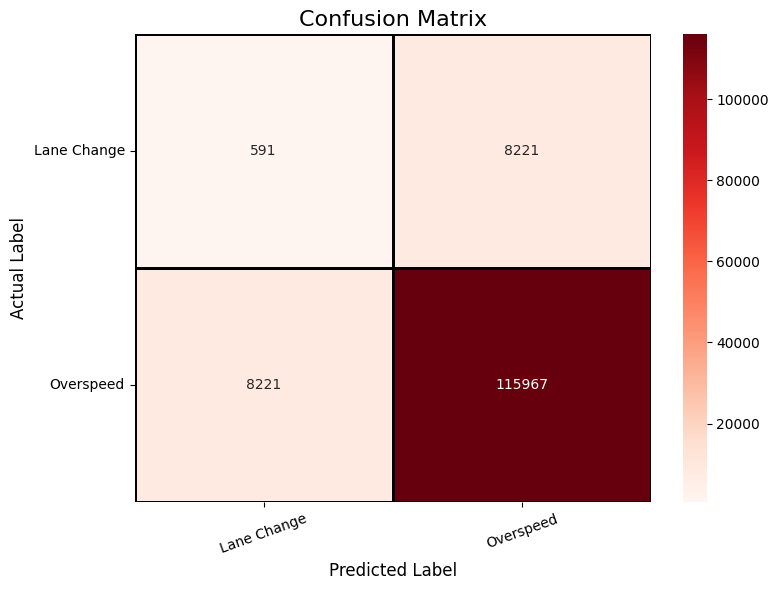

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_df,
    annot=True,          # show numbers
    fmt="d",             # integer format
    cmap="Reds",         # color theme
    cbar=True,           # show color scale bar
    linewidths=1,
    linecolor='black'
)

plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png")   # save image
plt.show()                            # display plot


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# ================= BINARY CONVERSION (Violation vs No Violation) =================
print("\n========== ROC & VALIDATION METRICS ==========")

merged["y_true_bin"] = merged["Violation_gt"].apply(lambda x: 0 if x == "No Violation" else 1)
merged["y_pred_bin"] = merged["Violation_pred"].apply(lambda x: 0 if x == "No Violation" else 1)

y_true_bin = merged["y_true_bin"]
y_pred_bin = merged["y_pred_bin"]

# ================= VALIDATION ACCURACY =================
val_accuracy = accuracy_score(y_true_bin, y_pred_bin)
print(f"✅ Validation Accuracy (Binary): {val_accuracy:.4f}")

# ================= ROC CURVE =================
fpr, tpr, thresholds = roc_curve(y_true_bin, y_pred_bin)
roc_auc = auc(fpr, tpr)

print(f"📈 AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Violation Detection")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.close()

# ================= OUTPUT FILES =================
print("\n📁 Files Saved:")
print("✔ classification_report.txt")
print("✔ confusion_matrix.csv")
print("✔ confusion_matrix.png")
print("✔ roc_curve.png")

print("\n✅ Evaluation Complete!")



========== ROC & VALIDATION METRICS ==========
✅ Validation Accuracy (Binary): 1.0000
📈 AUC Score: nan


C:\Users\DCL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(



📁 Files Saved:
✔ classification_report.txt
✔ confusion_matrix.csv
✔ confusion_matrix.png
✔ roc_curve.png

✅ Evaluation Complete!


Random Forest

Dataset Size: 464


C:\Users\DCL\AppData\Local\Temp\ipykernel_14680\2342952618.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Vehicle"] = vehicle_encoder.fit_transform(X["Vehicle"])



========== RANDOM FOREST RESULTS ==========
Accuracy : 98.92 %
Precision: 98.94 %
Recall   : 98.92 %
F1 Score : 98.88 %

Classification Report

              precision    recall  f1-score   support

 Lane Change       1.00      0.83      0.91         6
   Overspeed       0.99      1.00      0.99        87

    accuracy                           0.99        93
   macro avg       0.99      0.92      0.95        93
weighted avg       0.99      0.99      0.99        93



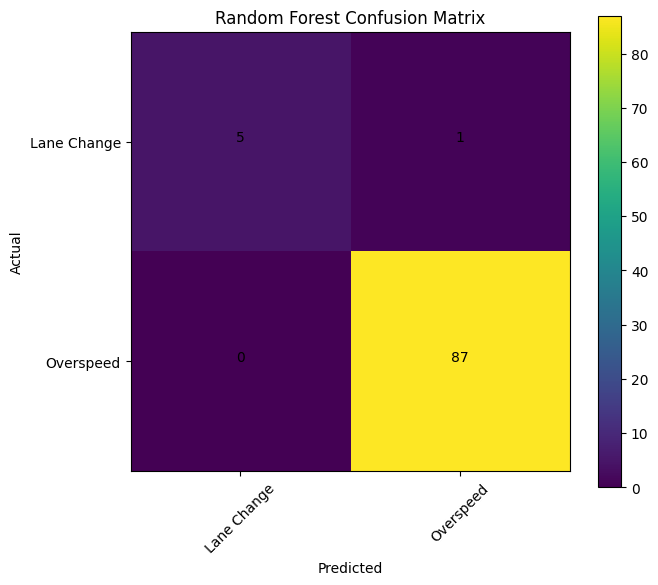

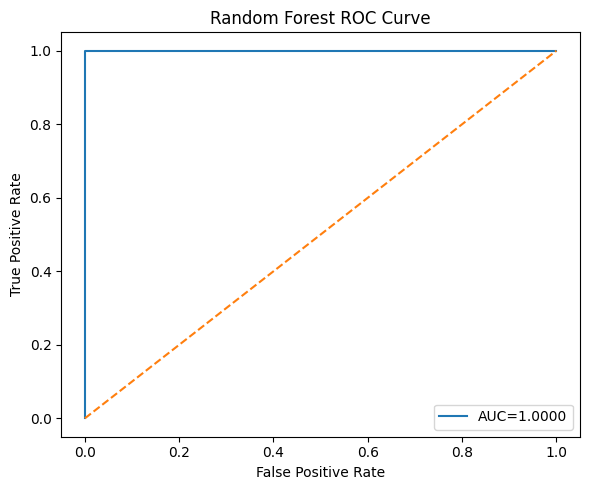

AUC Score: 1.0

Files Saved:
RF_classification_report.txt
RF_confusion_matrix.png
RF_ROC.png


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ================= LOAD DATA =================
df = pd.read_csv("traffic_violations.csv")

print("Dataset Size:", len(df))

# ================= CLEAN DATA =================
df["Plate"] = df["Plate"].fillna("Unknown")
df["Violation"] = df["Violation"].fillna("No Violation")

# ================= FEATURE SELECTION =================
X = df[["Vehicle","Speed"]]

y = df["Violation"]

# ================= ENCODING =================
vehicle_encoder = LabelEncoder()
X["Vehicle"] = vehicle_encoder.fit_transform(X["Vehicle"])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================= RANDOM FOREST =================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ================= PREDICTION =================
y_pred = model.predict(X_test)

# ================= METRICS =================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print("\n========== RANDOM FOREST RESULTS ==========")

print("Accuracy :", round(accuracy*100,2),"%")
print("Precision:", round(precision*100,2),"%")
print("Recall   :", round(recall*100,2),"%")
print("F1 Score :", round(f1*100,2),"%")

# ================= CLASSIFICATION REPORT =================
report = classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
)

print("\nClassification Report\n")
print(report)

with open("RF_classification_report.txt","w") as f:
    f.write(report)

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,6))
plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.colorbar()

classes = target_encoder.classes_

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("RF_confusion_matrix.png")
plt.show()

# ================= ROC CURVE =================
if len(np.unique(y_test)) == 2:

    y_prob = model.predict_proba(X_test)[:,1]

    fpr,tpr,_ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr,tpr)

    plt.figure(figsize=(6,5))
    plt.plot(
        fpr,
        tpr,
        label=f"AUC={roc_auc:.4f}"
    )

    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Random Forest ROC Curve")
    plt.legend()

    plt.tight_layout()
    plt.savefig("RF_ROC.png")
    plt.show()

    print("AUC Score:", roc_auc)

print("\nFiles Saved:")
print("RF_classification_report.txt")
print("RF_confusion_matrix.png")
print("RF_ROC.png")

XG Boost

In [103]:
pip install xgboost


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset Size: 464


C:\Users\DCL\AppData\Local\Temp\ipykernel_14680\1058042927.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Vehicle"] = vehicle_encoder.fit_transform(X["Vehicle"])



========== XGBOOST RESULTS ==========
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %

Classification Report

              precision    recall  f1-score   support

 Lane Change       1.00      1.00      1.00         6
   Overspeed       1.00      1.00      1.00        87

    accuracy                           1.00        93
   macro avg       1.00      1.00      1.00        93
weighted avg       1.00      1.00      1.00        93



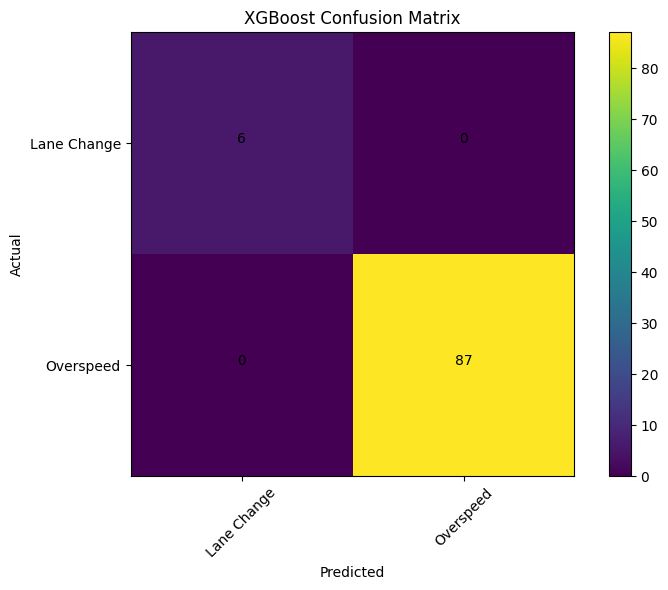

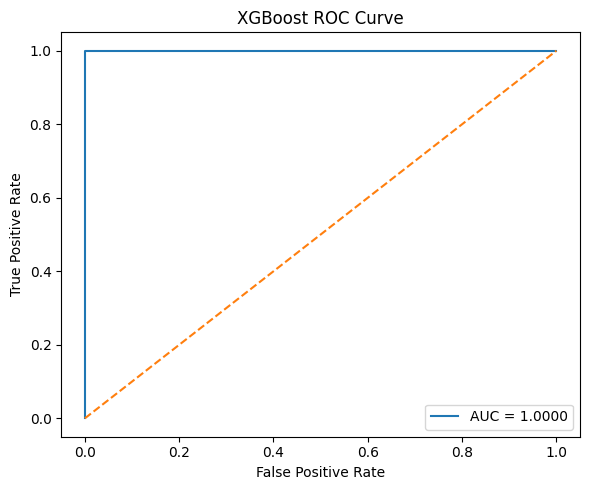


AUC Score: 1.0

📁 Files Saved:
✔ XGB_classification_report.txt
✔ XGB_confusion_matrix.png
✔ XGB_ROC.png


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ================= LOAD DATA =================
df = pd.read_csv("traffic_violations.csv")

print("Dataset Size:", len(df))

# ================= CLEAN DATA =================
df["Plate"] = df["Plate"].fillna("Unknown")
df["Violation"] = df["Violation"].fillna("No Violation")

# ================= FEATURES =================
X = df[["Vehicle", "Speed"]]
y = df["Violation"]

# ================= ENCODING =================
vehicle_encoder = LabelEncoder()
X["Vehicle"] = vehicle_encoder.fit_transform(X["Vehicle"])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

num_classes = len(np.unique(y))

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================= XGBOOST =================
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

# ================= PREDICTION =================
y_pred = model.predict(X_test)

# ================= METRICS =================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print("\n========== XGBOOST RESULTS ==========")

print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision*100,2), "%")
print("Recall   :", round(recall*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")

# ================= CLASSIFICATION REPORT =================
report = classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
)

print("\nClassification Report\n")
print(report)

with open("XGB_classification_report.txt", "w") as f:
    f.write(report)

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.title("XGBoost Confusion Matrix")
plt.colorbar()

classes = target_encoder.classes_

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha='center'
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("XGB_confusion_matrix.png")
plt.show()

# ================= ROC CURVE =================
if num_classes == 2:

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot([0,1], [0,1], '--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("XGBoost ROC Curve")
    plt.legend()

    plt.tight_layout()
    plt.savefig("XGB_ROC.png")
    plt.show()

    print("\nAUC Score:", round(roc_auc,4))

print("\n📁 Files Saved:")
print("✔ XGB_classification_report.txt")
print("✔ XGB_confusion_matrix.png")
print("✔ XGB_ROC.png")

In [105]:
pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


SVC

Dataset Size: 464

========== SVM RESULTS ==========
Accuracy : 98.92 %
Precision: 98.94 %
Recall   : 98.92 %
F1 Score : 98.88 %

Classification Report

              precision    recall  f1-score   support

 Lane Change       1.00      0.83      0.91         6
   Overspeed       0.99      1.00      0.99        87

    accuracy                           0.99        93
   macro avg       0.99      0.92      0.95        93
weighted avg       0.99      0.99      0.99        93



C:\Users\DCL\AppData\Local\Temp\ipykernel_14680\2393778937.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Vehicle"] = vehicle_encoder.fit_transform(X["Vehicle"])


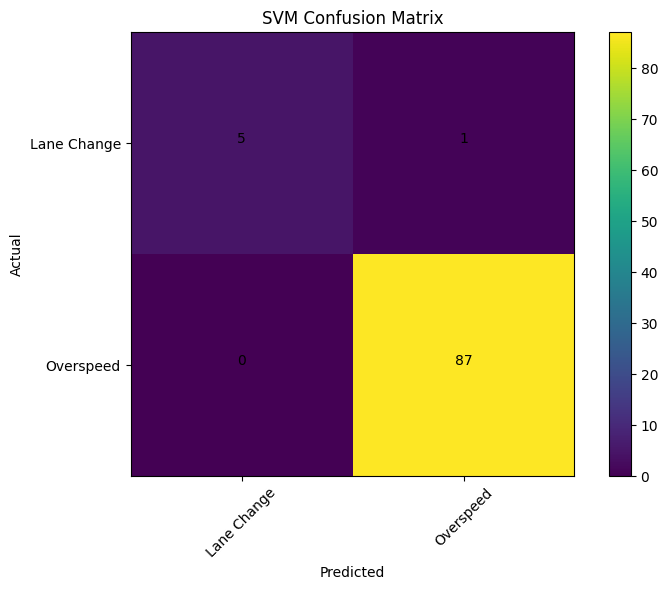

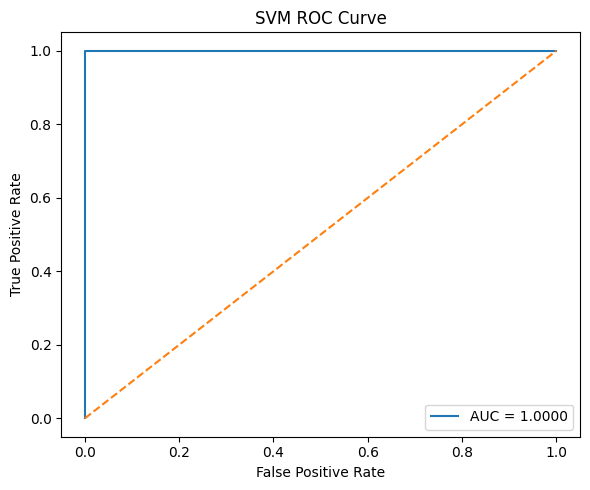


AUC Score: 1.0

📁 Files Saved:
✔ SVM_classification_report.txt
✔ SVM_confusion_matrix.png
✔ SVM_ROC.png


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ================= LOAD DATA =================
df = pd.read_csv("traffic_violations.csv")

print("Dataset Size:", len(df))

# ================= CLEAN DATA =================
df["Plate"] = df["Plate"].fillna("Unknown")
df["Violation"] = df["Violation"].fillna("No Violation")

# ================= FEATURES =================
X = df[["Vehicle", "Speed"]]
y = df["Violation"]

# ================= ENCODING =================
vehicle_encoder = LabelEncoder()
X["Vehicle"] = vehicle_encoder.fit_transform(X["Vehicle"])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

num_classes = len(np.unique(y))

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================= FEATURE SCALING =================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================= SVM MODEL =================
model = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42
)

model.fit(X_train, y_train)

# ================= PREDICTION =================
y_pred = model.predict(X_test)

# ================= METRICS =================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print("\n========== SVM RESULTS ==========")

print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision*100,2), "%")
print("Recall   :", round(recall*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")

# ================= CLASSIFICATION REPORT =================
report = classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
)

print("\nClassification Report\n")
print(report)

with open("SVM_classification_report.txt", "w") as f:
    f.write(report)

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.title("SVM Confusion Matrix")
plt.colorbar()

classes = target_encoder.classes_

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha='center'
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("SVM_confusion_matrix.png")
plt.show()

# ================= ROC CURVE =================
if num_classes == 2:

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot([0,1], [0,1], '--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("SVM ROC Curve")
    plt.legend()

    plt.tight_layout()
    plt.savefig("SVM_ROC.png")
    plt.show()

    print("\nAUC Score:", round(roc_auc,4))

print("\n📁 Files Saved:")
print("✔ SVM_classification_report.txt")
print("✔ SVM_confusion_matrix.png")
print("✔ SVM_ROC.png")